In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import tensorflow as tf
import tensorflow_probability as tfp


import re
import os
import copy
import warnings
import functools
import contextlib
import time

from scipy import stats
from decimal import Decimal
from datetime import datetime
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from bayes_opt import BayesianOptimization
from sklearn.metrics import confusion_matrix, classification_report, fbeta_score
from itertools import product


In [2]:
plt.style.use('dark_background')
pd.set_option("display.precision", 2)

tf.get_logger().setLevel('INFO')

seed = 1
tf.keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)
tf.config.experimental.enable_op_determinism()
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# Data Loading
df = pd.read_csv('data_incentive_attitudes_residencedata.csv')

# Some basic data preprocessing steps
df = df.drop(['X', 'trip','value','long_o', 'lat_o', 'long_d.x', 
              'lat_d.x', 'pincode', 'address','Prefecture', 'City', 
              'Town','lat_d.return','long_d.return', 'dest_inside'], axis='columns')
df = df.rename(columns={'pubcost':'traincost', 
                   'pubtime':'traintime', 
                   'pubavail':'trainavail',
                    'bicycleincentive':'bikeincentive'})

# Replacing 'pub' with 'train' in `mode` column.
selected_mode = df['mode'].to_numpy()
df['mode'] = np.where(selected_mode=='pub', 'train', selected_mode)

purpose_code_dict = {100: 'Commuting to work / school',
                    101: 'Go Home',
                    200: 'Shopping for daily necessities',
                    201: 'Shopping other than daily necessities',
                    202: 'Meals and entertainment',
                    300: 'business',
                    400: 'Outpatient',
                    500: 'Pick-up and drop-off',
                    600: 'Sightseeing / Leisure',
                    998: 'others'}

attitudinal_variables = [x for x in df.columns if bool(re.search(r'\d', x))]
ohe_generic_variables = dict()

df['walkavail'] = np.where(df['mode']=='walk', 1, np.where(df['cardistance']<=7, 1, 0))
df['busincentive'] = np.where(df['incentivezone']==1, df['busincentive'], 0)
df['carincentive'] = np.where(df['incentivezone']==1, df['carincentive'], 0)
df['trainincentive'] = np.where(df['incentivezone']==1, df['trainincentive'], 0)
df['bikeincentive'] = np.where(df['incentivezone']==1, df['bikeincentive'], 0)
df['walkincentive'] = np.where(df['incentivezone']==1, df['walkincentive'], 0)
df['motorincentive'] = np.where(df['incentivezone']==1, df['motorincentive'], 0)


In [4]:
# utility functions for extracting time-zones and trip duration information from arrival and departure times of a trip.

def get_trip_duration(df):
    """
    Returns the total minutes a trip lasted given its departure and arrival datetimes.
    """
    dep_datetime = datetime.strptime(df['departure_time'], '%m/%d/%Y %H:%M')
    arr_datetime = datetime.strptime(df['arrival_time'], '%m/%d/%Y %H:%M')
    
    return int((arr_datetime - dep_datetime).total_seconds()/60)

def get_day_zones(trip_datetime):
    """
    Divides the time into 4 zones and ordinally encoding them.
    Early morning (00:00 to 6:00) - 1
    AM peak (6:00 to 10:00) - 2
    Off peak (10:00 to 16:00) - 3
    PM peak (16:00 to 20:00) - 4
    Evening (20:00 to 00:00) - 5
    """
    dep_hrs, dep_mins = [int(val) for val in trip_datetime.split(' ')[1].split(':')]
    if dep_hrs >= 0 and dep_hrs < 6:
        return 1
    elif dep_hrs >= 6 and dep_hrs < 10:
        return 2
    elif dep_hrs >= 10 and dep_hrs < 16:
        return 3
    elif dep_hrs >= 16 and dep_hrs < 20:
        return 4
    else:
        return 5

ohe = OneHotEncoder()
df['high_income'] = np.where(df['INCOME'] >= 5, 1, 0)

# `job_type` column
job_type_sparse_matrix = ohe.fit_transform(df['job_type'].to_numpy().reshape(-1, 1)).toarray()
job_type_column_names = ['job_type_'+job for job in df['job_type'].unique()]
job_type_df = pd.DataFrame(data=job_type_sparse_matrix, columns=job_type_column_names)
job_type_df = job_type_df.drop(job_type_df.columns[0], axis=1)
ohe_generic_variables['jobs'] = list(job_type_df.columns)

# `information` column
info_sparse_matrix = ohe.fit_transform(df['information'].to_numpy().reshape(-1, 1)).toarray()
info_df = pd.DataFrame(data=info_sparse_matrix, columns=ohe.categories_[0])
info_df = info_df.drop(info_df.columns[0], axis=1)
ohe_generic_variables['info'] = list(info_df.columns)

# `SEX` column
SEX_sparse_matrix = ohe.fit_transform(df['SEX'].to_numpy().reshape(-1, 1)).toarray()
SEX_df = pd.DataFrame(data=SEX_sparse_matrix, columns=['Male', 'Female'])
SEX_df = SEX_df.drop(SEX_df.columns[0], axis=1)

# `Purpose` column
Purpose_sparse_matrix = ohe.fit_transform(df['Purpose'].to_numpy().reshape(-1, 1)).toarray()
Purpose_column_names = ['Purpose_'+str(purpose_code) for purpose_code in df['Purpose'].unique()]
Purpose_df = pd.DataFrame(data=Purpose_sparse_matrix, columns=Purpose_column_names)
Purpose_df = Purpose_df.drop('Purpose_999', axis=1)
ohe_generic_variables['purposes'] = list(Purpose_df.columns)

# Getting the trip duration in minutes
df['trip_duration'] = df[['departure_time', 'arrival_time']].T.apply(get_trip_duration)

# Converting departure time in time zones and one-hot encoding it
dep_time_zones_sparse_matrix = ohe.fit_transform(df['departure_time'].apply(get_day_zones).to_numpy().reshape(-1, 1)).toarray()
dep_time_zones_names = ['Early_morning_departure', 'AM_peak_departure', 'Off_peak_departure', 'PM_peak_departure', 'Night_departure']
dep_time_zones_df = pd.DataFrame(data=dep_time_zones_sparse_matrix, columns=dep_time_zones_names)
dep_time_zones_df = dep_time_zones_df.drop('Night_departure', axis=1)
ohe_generic_variables['departures'] = list(dep_time_zones_df.columns)

# combining all the one-hot encoded dataframes with the main dataframe
df2 = pd.concat([df, dep_time_zones_df, Purpose_df, SEX_df, job_type_df, info_df], axis=1).drop(
    ['departure_time', 'arrival_time', 'Purpose', 'SEX', 'job_type'], axis='columns')

# Removing some unnecessary columns
df2 = df2.drop(['user_id', 'trip_id', 'recco', 'information', 'incentivezone', 'task', 'income_con'], axis='columns')

df2.head()

,buscost,bustime,carcost,cartime,cardistance,traincost,traintime,walktime,walkcost,biketime,...,job_type_Part time job,job_type_Management executive,job_type_civil servant,job_type_Housewife,job_type_Self employed/ Freelance,job_type_Others,job_type_Unemployed,no info,only enviro,only health
0,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,690,66.2,128.6,38.96,12.86,240,44.9,154.32,0,51.44,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,500,56.2,118.5,29.53,11.85,400,59.0,142.20,0,47.40,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,770,69.4,151.7,43.72,15.17,240,60.9,182.04,0,60.68,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


## Train and Test Split

In [5]:
def get_CBD_data_split(df, drop_att_vars=True, apply_smote=False, apply_tomek_links=False,
                      apply_standardization=False, cols_to_standardize=[]):
    if drop_att_vars:
        df = df.drop(attitudinal_variables, axis='columns')
        
        oCBD_df = df.loc[df['address_inside'] == False]
        iCBD_df = df.loc[(df['address_inside'] == True)]
        
        label_mapping_dict = {'bus': 1, 'car': 2, 'train': 3, 'walk': 4, 'bike': 5, 'motor': 6}
                
        y_oCBD = np.array([label_mapping_dict[label] for label in oCBD_df['mode']])
        X_oCBD = oCBD_df.drop('mode', axis='columns')
        y_iCBD = np.array([label_mapping_dict[label] for label in iCBD_df['mode']])
        X_iCBD = iCBD_df.drop('mode', axis='columns')
        
        if apply_smote:
            smote = SMOTE(random_state=500)
            X_oCBD, y_oCBD = smote.fit_resample(X_oCBD, y_oCBD)
            X_iCBD, y_iCBD = smote.fit_resample(X_iCBD, y_iCBD)
        
        if apply_tomek_links:
            tomek = TomekLinks()
            X_oCBD, y_oCBD = tomek.fit_resample(X_oCBD, y_oCBD)
            X_iCBD, y_iCBD = tomek.fit_resample(X_iCBD, y_iCBD)
        
        if apply_standardization:
            ss =  StandardScaler()
            X_oCBD_scaled_arr = ss.fit_transform(X_oCBD[cols_to_standardize])
            X_iCBD_scaled_arr = ss.transform(X_iCBD[cols_to_standardize])
            X_oCBD_scaled = pd.DataFrame(X_oCBD_scaled_arr, columns=cols_to_standardize)
            X_iCBD_scaled = pd.DataFrame(X_iCBD_scaled_arr, columns=cols_to_standardize)
            X_oCBD_scaled.set_index(X_oCBD.index, inplace=True)
            X_iCBD_scaled.set_index(X_iCBD.index, inplace=True)
            X_oCBD.iloc[0:X_oCBD.shape[0], X_oCBD.columns.get_indexer(cols_to_standardize)] = X_oCBD_scaled
            X_iCBD.iloc[0:X_iCBD.shape[0], X_iCBD.columns.get_indexer(cols_to_standardize)] = X_iCBD_scaled
        
        return ((X_oCBD, y_oCBD), (X_iCBD, y_iCBD)), label_mapping_dict
    

In [6]:
output_categories = ['bus', 'car', 'train', 'walk', 'bike', 'motor']

asc_variable_names = {
    'bus': ['buscost', 'bustime', 'busincentive'],
    'car': ['carcost', 'cartime', 'carincentive'],
    'train': ['traincost', 'traintime', 'trainincentive'], 
    'walk': ['walkcost', 'walktime', 'walkincentive'],
    'bike': [ 'bikecost', 'biketime', 'bikeincentive'],
    'motor': ['motorcost', 'motortime', 'motorincentive']
}

avail_variable_names = {
    'bus': 'busavail',
    'train': 'trainavail',
    'walk': 'walkavail',
    'bike': 'bikeavail',
    'motor': 'motoravail'
}

cols_to_standardize = ['AGE', 'nearest_bus_dist', 'nearest_train_dist']
for category in output_categories:
    cols_to_standardize.extend(asc_variable_names[category])

In [7]:
((X_oCBD, y_oCBD), (X_iCBD, y_iCBD)), label_mapping_dict = get_CBD_data_split(df2, drop_att_vars=True)

In [8]:
print("Main model training data (outside CBD):", y_oCBD.shape[0])
print("Target region data (inside CBD):", y_iCBD.shape[0])

Main model training data (outside CBD): 1851
Target region data (inside CBD): 1235


In [9]:
def get_generic_vars_names(asc_variable_names, avail_variable_names):
    asc_variables_list = []
    for category_asc_variables in asc_variable_names.values():
        asc_variables_list.extend(category_asc_variables)
    return list(X_oCBD.drop(asc_variables_list, axis=1, errors='ignore').drop(
        avail_variable_names.values(), axis=1, errors='ignore').columns)

generic_variable_names = get_generic_vars_names(asc_variable_names, avail_variable_names)
for item in ['cardistance', 'trip_duration']:
    if item in generic_variable_names:
        generic_variable_names.remove(item)

asc_variable_indexer = dict()
for category in output_categories:
    asc_variable_indexer[category] = X_oCBD.columns.get_indexer(asc_variable_names[category])

avail_variable_indexer = dict(zip(avail_variable_names.keys(), 
                                  X_oCBD.columns.get_indexer(avail_variable_names.values())))

generic_variable_indexer = dict(zip(generic_variable_names, 
                                  X_oCBD.columns.get_indexer(generic_variable_names)))

# <ins><b>Model Formulation</b></ins>

In [10]:
# Helper functions

def make_val_and_grad_fn(value_fn):
    @functools.wraps(value_fn)
    def val_and_grad(x):
        return tfp.math.value_and_gradient(value_fn, x)
    return val_and_grad

@contextlib.contextmanager
def timed_execution():
    t0 = time.time()
    yield
    dt = time.time() - t0
    print('Evaluation took: %f seconds' % dt)


def np_value(tensor):
    """Get numpy value out of possibly nested tuple of tensors."""
    if isinstance(tensor, tuple):
        return type(tensor)(*(np_value(t) for t in tensor))
    elif isinstance(tensor, list):
        return [t.numpy()[0] for t in tensor]
    else:
        return tensor.numpy()

def run(optimizer):
    """Run an optimizer and measure it's evaluation time."""
    optimizer()
    with timed_execution():
        result = optimizer()
    return np_value(result)

class Results():
    def __init__(self):
        position = []

        
class HistoryLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        super(HistoryLogger, self).__init__()
        self.history = {}
    
    def on_train_begin(self, logs=None):
        self.history = {}
    
    def on_epoch_begin(self, epoch, logs=None):
        for key, value in logs.items():
            self.history.setdefault(key, []).append(value)
    
    def on_epoch_end(self, epoch, logs=None):
        for key, value in logs.items():
            self.history.setdefault(key, []).append(value)
    
    def on_train_end(self, logs=None):
        if logs.get('plot_loss', False):
            plt.plot(np.arange(len(self.history['loss_train'])), self.history['loss_train'], label='train loss')
        if logs.get('plot_f2_train', False):
            plt.plot(np.arange(len(self.history['f2_train'])), self.history['f2_train'], label='train f2')
        if logs.get('plot_f2_val', False):
            plt.plot(np.arange(len(self.history['f2_val'])), self.history['f2_val'], label='validation f2')
            plt.legend()
        
history = HistoryLogger()

In [11]:
def generate_avail_data(X_tensor):
    avail_vals = []
    for cat in output_categories:
        if cat in avail_variable_names:
            avail_vals.append(X_tensor[:, avail_variable_indexer[cat]])
        else:
            avail_vals.append(tf.ones(X_tensor.shape[0], dtype='float32'))
    return tf.stack(avail_vals)



def create_alt_spec_params(alternatives, name, gu_values, val_count):
    """
    alternatives (list of str): Names of various corresponding to which this variable should be created.
    name (str): The name of this variable.
    """
    alt_spec_vars = []
    if name == 'nearest_bus_dist':
        alternative='bus'
        alt_spec_var = tf.Variable([gu_values[val_count]], dtype='float32', 
                        name=f'{name}_{alternative}', trainable=True)
        val_count += 1
        alt_spec_vars.append(alt_spec_var)
        
    elif name == 'nearest_train_dist':
        alternative='train'
        alt_spec_var = tf.Variable([gu_values[val_count]], dtype='float32', 
                        name=f'{name}_{alternative}', trainable=True)
        val_count += 1
        alt_spec_vars.append(alt_spec_var)
        
    else:
        for alternative in alternatives:
            alt_spec_var = tf.Variable([gu_values[val_count]], dtype='float32', 
                            name=f'{name}_{alternative}', trainable=True)
            val_count += 1
            alt_spec_vars.append(alt_spec_var)
    return alt_spec_vars, val_count



def initiate_params(alt_spec_vars=True, ind_spec_vars_list=None):
    model_params = []
    
    gu_values = tf.keras.initializers.glorot_uniform(seed=1)(shape=(200,))*0
    val_count = 0
    
    if alt_spec_vars:
        # Generic parameters for alternative specific variables of travelcost, traveltime, travelincentive
        gen_tc = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='travelcost', trainable=True)
        val_count += 1
        gen_tt = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='traveltime', trainable=True)
        val_count += 1
        gen_ti = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='travelincentive', trainable=True)
        val_count += 1
        model_params.extend([gen_tc, gen_tt, gen_ti])

        # Alternative specific constants for bus, train, walk, bike, motor
        asc_bus = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='bus_constant', trainable=True)
        val_count += 1
        asc_train = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='train_constant', trainable=True)
        val_count += 1
        asc_walk = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='walk_constant', trainable=True)
        val_count += 1
        asc_bike = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='bike_constant', trainable=True)
        val_count += 1
        asc_motor = tf.Variable([gu_values[val_count]], dtype=tf.float32, name='motor_constant', trainable=True)
        val_count += 1
        model_params.extend([asc_bus, asc_train, asc_walk, asc_bike, asc_motor])
    
    if ind_spec_vars_list is not None:
        alternatives = ['bus', 'train', 'walk', 'bike', 'motor']
        for var in ind_spec_vars_list:
            isv_asp_params, val_count = create_alt_spec_params(alternatives, var, gu_values, val_count)
            model_params.extend(isv_asp_params)
    
    return model_params


def utilities(x_name, x_val, params, alt_spec_vars=True, ind_spec_vars_list=None):
    x_val = tf.convert_to_tensor(x_val, dtype='float32')
    ntrips = x_val.shape[-1]
    X = dict()
    x_val_trans = tf.transpose(x_val)
    for i, name in enumerate(x_name):
        val = x_val_trans[i]
        X[name] = val
            
    if alt_spec_vars:
        # Contribution to utility from tc, tt, ti
        travel_util_bus = X['buscost'] * params[0] + X['bustime'] * params[1] + X['busincentive'] * params[2] + params[3]
        travel_util_train = X['traincost'] * params[0] + X['traintime'] * params[1] + X['trainincentive'] * params[2] + params[4]
        travel_util_walk = X['walktime'] * params[1] + X['walkincentive'] * params[2] + params[5]  # walkcost is 0
        travel_util_bike = X['biketime'] * params[1] + X['bikeincentive'] * params[2] + params[6]  # bikecost is 0
        travel_util_motor = X['motorcost'] * params[0] + X['motortime'] * params[1] + X['motorincentive'] * params[2] + params[7]
        travel_util_car = X['carcost'] * params[0] + X['cartime'] * params[1] + X['carincentive'] * params[2]

        utility_bus = travel_util_bus
        utility_car = travel_util_car
        utility_train = travel_util_train
        utility_walk = travel_util_walk
        utility_bike = travel_util_bike
        utility_motor = travel_util_motor

    if ind_spec_vars_list is not None:
        nparams = params.shape[0]
        param_count = 0
        var_count = 0
        for i in range(8, nparams):
            isv_asp_param = params[i]
            var_name = ind_spec_vars_list[var_count]
            isv_util = X[var_name] * isv_asp_param
            
            if var_name == 'nearest_bus_dist':
                utility_bus += isv_util
                var_count += 1
                
            elif var_name == 'nearest_train_dist':
                utility_train += isv_util
                var_count += 1
        
            else:
                utility_bus += tf.where(tf.equal(param_count, 0), isv_util, 0.0)
                utility_train += tf.where(tf.equal(param_count, 1), isv_util, 0.0)
                utility_walk += tf.where(tf.equal(param_count, 2), isv_util, 0.0)
                utility_bike += tf.where(tf.equal(param_count, 3), isv_util, 0.0)
                utility_motor += tf.where(tf.equal(param_count, 4), isv_util, 0.0)
                
                param_count += 1
                param_count = param_count % 5
                if param_count == 0:
                    var_count += 1

    return tf.transpose(tf.stack((utility_bus, utility_car, utility_train, utility_walk, utility_bike, utility_motor)))


In [12]:
def initialize_layers(activation_layer, layers=0, nodes=[6], seed=1):
    non_linear_layers = []
    for i in range(layers):
        non_linear_layers.append(tf.keras.layers.Dense(
                                    nodes[i], 
                                    activation=activation_layer, 
                                    kernel_initializer = tf.keras.initializers.GlorotUniform(seed=seed),
                                    bias_initializer = tf.keras.initializers.GlorotUniform(seed=seed)
                                ))
    return non_linear_layers



def get_logits(x_name, x_val, params, alt_spec_vars=True, ind_spec_vars_list=None, layers_list = [], debug=False):
    utils = utilities(x_name, x_val, params, alt_spec_vars=alt_spec_vars, 
                      ind_spec_vars_list=ind_spec_vars_list)
    if debug:
        print("utils:", utils)
        print("-----------------------")
    
    for i, dense_layer in enumerate(layers_list):
        utils = dense_layer(utils)
        if debug:
            print(f"Non-linear layer {i}:", utils)
            print("------------------------------")
    
    return utils


def loss(true_y, logits, avail_vals, null_loglike=False):
    initial_probs = tf.nn.softmax(logits)
    masked_probs = initial_probs*tf.transpose(avail_vals)
    final_probs = tf.divide(masked_probs, 
                            tf.reshape((tf.reduce_sum(masked_probs, axis=-1) + tf.keras.backend.epsilon()), 
                                       [-1, 1])
                           )
    if null_loglike:
        final_probs = tf.where(final_probs!=0, 1, final_probs)
        final_probs = tf.divide(final_probs,
                                tf.reshape(tf.reduce_sum(final_probs, axis=-1)+tf.keras.backend.epsilon(),
                                          [-1, 1])
                               )
    ce_loss = -tf.reduce_sum(tf.reduce_sum(true_y*tf.math.log(
        final_probs + tf.keras.backend.epsilon()), axis=-1))
    return ce_loss


def apply_regularization(loss, params, l1_lambda=0.001, l2_lambda=0.001):
    # Applying l2 penalty on parameters of alternative specific variables
    l2_penalty = l2_lambda*tf.reduce_sum(tf.math.square(params[:3]))
    
    # Applying l1 penalty on paramters of individual specific variables
    l1_penalty = l1_lambda*tf.reduce_sum(tf.math.abs(params[8:]))
    
    return loss + l1_penalty + l2_penalty


def predict(x_name, x_val, params, avail_vals, alt_spec_vars=True, ind_spec_vars_list=None, layers_list=[]):
    """
    Returns the final probabilites and mode predictions
    """
    utils = get_logits(x_name, x_val, params, alt_spec_vars=True, 
                       ind_spec_vars_list=ind_spec_vars_list, layers_list=layers_list)
    initial_probs = tf.nn.softmax(utils)
    masked_probs = initial_probs*tf.transpose(avail_vals)
    final_probs = tf.divide(masked_probs, 
                            tf.reshape((tf.reduce_sum(masked_probs, axis=-1) + tf.keras.backend.epsilon()), 
                                       [-1, 1])
                           )
    
    return final_probs, tf.argmax(final_probs, axis=1)

## Training

In [13]:
# def loss_val_nd_loss_grad(x_names, x_vals, params, l1_lambda, l2_lambda, ind_spec_vars=None, layers_list=[]):
#     curr_utils = get_logits(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars, 
#                             layers_list=layers_list)
#     curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
#     penalty_loss = apply_regularization(curr_loss, params, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
#     return np_value(penalty_loss)

In [14]:
# Optimizer functions for BFGS method
@tf.function
def mnl_bfgs(l1_lambda, l2_lambda):
    
    @make_val_and_grad_fn
    def loss_val_nd_loss_grad(params):
        curr_utils = utilities(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars)
        curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
        penalty_loss = apply_regularization(curr_loss, params, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
        return penalty_loss
    
    def mnl_with_bfgs():
        return tfp.optimizer.bfgs_minimize(loss_val_nd_loss_grad, 
                                          initial_position=tf.reshape(params, shape=[-1]),
                                          tolerance=1e-8,
                                          max_iterations=1000)
    return mnl_with_bfgs()
        

def outer_mnl_bfgs(l2_lambda, l1_lambda, return_res=False):
    l1_lambda = tf.convert_to_tensor(l1_lambda, dtype=tf.float32)
    l2_lambda = tf.convert_to_tensor(l2_lambda, dtype=tf.float32)
    
    result_tensor = mnl_bfgs(l1_lambda, l2_lambda)
    
    results = np_value(result_tensor)
    y_pred = predict(x_names, x_vals, results.position, avail_vals, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1
    
    if return_res:
        return results
    
    return fbeta_score(y_oCBD, y_pred, beta=2, average='weighted')


In [52]:
def LL_gradient(x_names, x_vals, params, avail_vals, ohe_true_y, ind_spec_vars, l1_lambda, l2_lambda):
    shapes = tf.shape_n(params)
    n_tensors = len(shapes)

    count = 0
    idx =  [] 
    part = []

    for i, shape in enumerate(shapes):
        n = np.product(shape)
        idx.append(tf.reshape(tf.range(count, count+n, dtype=tf.int32), shape))
        part.extend([i]*n)
        count += n
        
    @tf.function
    def assign_new_model_parameters(params_1d):
        updated_params = tf.dynamic_partition(params_1d, part, n_tensors)
        for i, (shape, param) in enumerate(zip(shapes, updated_params)):
            params[i].assign(tf.reshape(param, shape))
            
    @tf.function 
    def est_grad(params_1d):
        with tf.GradientTape() as tape: 
            assign_new_model_parameters(params_1d)
            curr_utils = utilities(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars)
            curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
            penalty_loss = apply_regularization(curr_loss, params, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
        estimated_grad = tape.gradient(penalty_loss, params)
        grads_1dim = tf.dynamic_stitch(idx, estimated_grad)
        return penalty_loss, grads_1dim
    
    est_grad.idx = idx
    return est_grad

In [53]:
# def mnl_adam(l1_lambda, l2_lambda, epochs, optimizer, params, layers_list, 
#              x_names, x_vals, avail_vals, ohe_true_y):
    
#     history.on_train_begin()
    
#     def loss_val(params, debug=False):
#         curr_utils = get_logits(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars, 
#                                 layers_list=layers_list, debug=debug)
#         curr_loss = loss(ohe_true_y, curr_utils, avail_vals)
#         penalty_loss = apply_regularization(curr_loss, params, l1_lambda=l1_lambda, l2_lambda=l2_lambda)
#         return penalty_loss
    
    
#     def train(i, debug=False, add_history=True):
#         with tf.GradientTape() as tape:
#             loss = loss_val(params, debug=debug)
#         grads = tape.gradient(loss, params)
#         optimizer.apply_gradients(zip(grads, params))
#         if add_history:
#             history.on_epoch_end(i, logs={'loss_train':loss}) # CALLBACK
    
#     def mnl_with_adam():
#         for i in tf.range(epochs):
#             curr_lr = optimizer.lr.numpy()
#             history.on_epoch_begin(i, logs={'lr':curr_lr})
#             train(i, add_history=True)
#         history.on_train_end(logs={'plot_loss':True}) # CALLBACK
#         return params
    
#     return mnl_with_adam()
            
    

# def outer_mnl_adam(l1_lambda, l2_lambda, epochs, optimizer, params, layers_list, 
#                    x_names, x_vals, avail_vals, ohe_true_y):
    
#     l1_lambda = tf.convert_to_tensor(l1_lambda, dtype=tf.float32)
#     l2_lambda = tf.convert_to_tensor(l2_lambda, dtype=tf.float32)
#     params = copy.deepcopy(params)
#     epochs = tf.convert_to_tensor(epochs)
    
#     results_list_tensor = mnl_adam(l1_lambda, l2_lambda, epochs, optimizer, 
#                                    params, layers_list, 
#                                    x_names, x_vals, avail_vals, ohe_true_y)
#     results = np_value(results_list_tensor)
    
#     return results
    
    

In [54]:
# def get_cv_results(X, y, outer_skf, inner_skf, debug=False):
#     best_score = 0
#     best_params = ()
#     for train_indices, test_indices in outer_skf.split(X, y):
#         X_train, y_train = X[train_indices], y[train_indices]
#         X_test, y_test = X[test_indices], y[test_indices]
        
#         avail_vals_train = generate_avail_data(X_train)
#         avail_vals_test = generate_avail_data(X_test)
#         ohe_true_y_train = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
        
        
#         params_tuple, train_score = inner_cv_results(X_train, y_train, inner_skf, debug)
#         (epoch, initial_lr, decay_rate, layers_count, neurons_count, activation_layer, seed) = params_tuple        
#         # Use the best params to train a model on X_train and y_train and evaluation on X_test, y_test
#         decay_steps = int(epoch/2)
#         learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=initial_lr,
#                                     decay_steps=decay_steps, decay_rate=decay_rate, staircase=False)
#         optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
#         nodes = []
#         for _ in range(layers_count-1):
#             nodes.append(neurons_count)
#         nodes.append(6)
#         layers_list = initialize_layers(activation_layer, layers=layers_count, nodes=nodes, seed=seed)
#         results = outer_mnl_adam(0, 0, epoch, optimizer, params, layers_list, 
#                                 x_names, X_train, avail_vals_train, ohe_true_y_train)
#         ypred_test_prob, y_pred_test = predict(x_names, X_test, results, avail_vals_test, 
#                         ind_spec_vars_list=ind_spec_vars, layers_list=layers_list)
#         test_score = fbeta_score(y_test, y_pred_test, beta=2, average='macro')
#         if best_score < test_score:
#             best_params = params_tuple
#             best_score = test_score
#     return params_tuple, best_score

# def inner_cv_results(X, y, inner_skf, debug):
#     epochs_list = [100, 1000]
#     initial_lr_list = [0.1, 0.01]
#     decay_rate_list = [0.01, 0.0001, 0.000001]
#     layers_count_list = [2, 5]
#     neurons_count_list = [10, 15]
#     activation_func_list = [tf.math.sigmoid, tf.keras.activations.swish, tf.math.softplus]
    
#     list_combos = [epochs_list, initial_lr_list, decay_rate_list, 
#                    layers_count_list, neurons_count_list, activation_func_list]
    
#     hparams_score_dict = dict()
    
#     for i, h_params in enumerate(product(*list_combos)):
#         epoch, initial_lr, decay_rate, layers_count, neurons_count, activation_func = h_params
#         val_f2_scores_list = []
#         print(h_params, end=' ')
        
#         for _ in range(10):
#             seed = np.random.randint(1, 10000)
#             print(seed, end=" ")
#             for inner_train_indices, val_indices in inner_skf.split(X, y):
#                 X_itrain, y_itrain = X[inner_train_indices], y[inner_train_indices]
#                 X_val, y_val = X[val_indices], y[val_indices]

#                 avail_vals_train = generate_avail_data(X_itrain)
#                 avail_vals_val = generate_avail_data(X_val)
#                 ohe_true_y_train = tf.one_hot(y_itrain-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')


#                 def param_opt(epochs, initial_lr, d_r, layers, neurons, seed, activation_layer):
#                     d_s = int(epochs*0.5)
#                     nodes = []
#                     for _ in range(layers-1):
#                         nodes.append(neurons)
#                     nodes.append(6)
#                     layers_list = initialize_layers(activation_layer, layers=layers, nodes=nodes, seed=seed)
#                     learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
#                                                                               initial_learning_rate=initial_lr,
#                                                                               decay_steps=d_s,
#                                                                               decay_rate=d_r,
#                                                                               staircase=False
#                                                                             )
#                     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)
#                     results = outer_mnl_adam(0, 0, epochs, optimizer, params, layers_list, 
#                                                       x_names, X_itrain, avail_vals_train, ohe_true_y_train)
#                     y_pred_probs, y_pred_val = predict(x_names, X_val, results, avail_vals_val, 
#                                      ind_spec_vars_list=ind_spec_vars, layers_list=layers_list)
#                     return fbeta_score(y_val, y_pred_val, beta=2, average='macro')

                
#                 val_f2_score = param_opt(epoch, initial_lr, decay_rate, layers_count, 
#                                               neurons_count, seed, activation_func)    
#                 val_f2_scores_list.append(val_f2_score)

#             mean_f2_score = np.mean(val_f2_scores_list)
#             hparams_tuple = (epoch, initial_lr, decay_rate, layers_count, neurons_count, activation_func, seed)
#             hparams_score_dict[hparams_tuple] = mean_f2_score
#             if debug:
#                 print(np.round(mean_f2_score, 3))
    
#     best_hparams_tuple = ()
#     best_hparams_score = 0
#     for hparam_tuple, score in hparams_score_dict.items():
#         if best_hparams_score < score:
#             best_hparams_score = score
#             best_hparams_tuple = hparam_tuple
#     return best_hparams_tuple, best_hparams_score

In [55]:
# %%time
# outer_skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=500)
# inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=500)

# best_params_tuple, f2_score = get_cv_results(X_oCBD.values, y_oCBD, outer_skf, inner_skf, debug=True)

In [56]:
# best_params_tuple
#(1000, 0.01, 0.0001, 5, 10, <function keras.activations.swish(x)>, 190)

In [57]:
# for i in range(5):
#     seed = np.random.randint(5000, 9999999)
#     seed = 1
#     activation_layer = tf.keras.activations.sigmoid
#     layers_list = initialize_layers(activation_layer, layers=5, nodes=[8, 8, 8, 8, 6], seed=seed)

#     epochs = 1000
#     initial_learning_rate = 0.01
#     decay_steps = epochs*0.5
#     decay_rate = 0.01
#     lambda1 = 0; lambda2 = 0

#     learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=initial_learning_rate,
#                                                                   decay_steps=decay_steps,
#                                                                   decay_rate=decay_rate,
#                                                                   staircase=False)
#     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, amsgrad=True)

#     results = Results()
#     x_vals = X_oCBD.values
#     avails_vals = generate_avail_data(avail_vals)
#     ohe_true_y = tf.one_hot(y_oCBD-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')

#     results.position = outer_mnl_adam(lambda1, lambda2, epochs, optimizer, params, layers_list,
#                                                x_names, x_vals, avail_vals, ohe_true_y)

#     y_prob_train, y_pred_train = predict(x_names, x_vals, results.position, avail_vals, 
#                            ind_spec_vars_list=ind_spec_vars, layers_list=layers_list)
#     f2_train = fbeta_score(y_oCBD, y_pred_train, beta=2, average='macro')

#     print(f"{i}th Adam Results with seed {seed}")
#     print("Parameters:", results.position)
#     print(f"F2 train: {f2_train:.3f}")

In [58]:
ind_spec_vars = ['AGE', 'Female', 'high_income', 'nearest_bus_dist', 'nearest_train_dist',]
#                  'Early_morning_departure','AM_peak_departure', 'Off_peak_departure', 
#                  'PM_peak_departure',
#                  'Purpose_101', 'Purpose_998', 'Purpose_100', 
#                  'Purpose_300', 'Purpose_200', 'Purpose_400', 'Purpose_600', 
#                  'Purpose_500', 'Purpose_202', 'Purpose_201',
#                  'job_type_Part time job', 'job_type_Management executive', 
#                  'job_type_civil servant', 'job_type_Housewife',
#                  'job_type_Self employed/ Freelance', 'job_type_Others', 
#                  'job_type_Unemployed']
#ind_spec_vars= ['nearest_bus_dist', 'nearest_train_dist']
ind_spec_vars=None

config_dict = {
    'Training Data': 'Outside CBD',
    'Testing Data': 'Inside CBD',
    'param intialization': 'zero initialization',
    'evaluation metric': 'F2',
    'ind_spec_vars': ind_spec_vars,
    'lambda1': 0,
    'lambda2': 0
}

In [59]:
def initialise_model_vars(X_df, y_arr):
    params = initiate_params(ind_spec_vars_list=ind_spec_vars)
    ohe_true_y = tf.one_hot(y_arr-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
    x_names = X_df.columns
    x_vals = X_df.values
    avail_vals = generate_avail_data(x_vals)
    return x_names, x_vals, avail_vals, ohe_true_y, params

In [60]:
x_names, x_vals, avail_vals, ohe_true_y, params = initialise_model_vars(X_oCBD, y_oCBD)

In [61]:
init_params = tf.dynamic_stitch(LL_gradient(x_names, x_vals, params, avail_vals, ohe_true_y, ind_spec_vars, 0, 0).idx, params)

In [69]:
results = tfp.optimizer.bfgs_minimize(
                              value_and_gradients_function=LL_gradient(x_names, x_vals, params, avail_vals, ohe_true_y, ind_spec_vars, 0, 0), 
                              initial_position=init_params,
                              tolerance=1e-08,
                              max_iterations=500)

In [23]:
# %%time
# hparams_range = {'l2_lambda': (0, 1), 'l1_lambda':(0, 10000)}
# bo = BayesianOptimization(outer_mnl_bfgs, hparams_range, random_state=200, allow_duplicate_points=True, verbose=1)
# bo.maximize(init_points=300, n_iter=100)

In [71]:
# lambda1 = 0
# lambda2 = 0
# config_dict['lambda1'] = lambda1
# config_dict['lambda2'] = lambda2

# results = outer_mnl_bfgs(lambda2, l1_lambda=lambda1, return_res=True)

print("BFGS Results")
print("Parameters:", results.position.numpy())
print("Converged:", results.converged.numpy())
print("Iterations:", results.num_iterations.numpy())
#print(f"Validation F2 score: {val_f2:.3f}")

BFGS Results
Parameters: [-0.00243883 -0.05643418  0.00363528 -0.5311894  -0.86371666  0.12339422
 -0.6833264  -1.1309592 ]
Converged: True
Iterations: 21


In [72]:
train_logits = get_logits(x_names, x_vals, results.position, ind_spec_vars_list=ind_spec_vars).numpy()
train_loglike = (loss(ohe_true_y, train_logits, avail_vals)*-1).numpy()
y_pred = predict(x_names, x_vals, results.position, 
                 avail_vals, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1
print("weighted Training region f2:", fbeta_score(y_oCBD, y_pred, beta=2, average='weighted'))
print("macro Training region f2:", fbeta_score(y_oCBD, y_pred, beta=2, average='macro'))
print("Training likelihood:", train_loglike)

config_dict['train_score_weighted'] = fbeta_score(y_oCBD, y_pred, beta=2, average='weighted')
config_dict['train_score_macro'] = fbeta_score(y_oCBD, y_pred, beta=2, average='macro')

weighted Training region f2: 0.688203122937688
macro Training region f2: 0.28591417135592806
Training likelihood: -1313.8009


In [73]:
ohe_true_y_test = tf.one_hot(y_iCBD-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
test_logits = get_logits(x_names, X_iCBD.values, results.position, ind_spec_vars_list=ind_spec_vars).numpy()
test_likelihood = (loss(ohe_true_y_test, test_logits, generate_avail_data(X_iCBD.values))*-1).numpy()

y_pred_target = predict(x_names, X_iCBD.values, results.position, 
                                       generate_avail_data(X_iCBD.values), 
                                       ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1
f2_target = fbeta_score(y_iCBD, y_pred_target, beta=2, average='weighted')

print("weighted Target region f2:", f2_target)
print("macro Target region f2:", fbeta_score(y_iCBD, y_pred_target, beta=2, average='macro'))
print("Target region likelihood:", test_likelihood/X_iCBD.shape[0])

config_dict['test_score_weighted'] = fbeta_score(y_iCBD, y_pred_target, beta=2, average='weighted')
config_dict['test_score_macro'] = fbeta_score(y_iCBD, y_pred_target, beta=2, average='macro')

weighted Target region f2: 0.49924929264800133
macro Target region f2: 0.21110626279599146
Target region likelihood: -1.0177056316422064


In [74]:
train_null_loglike = loss(ohe_true_y, train_logits, avail_vals, null_loglike=True)
train_null_loglike = train_null_loglike.numpy()*-1
inital_train_logits = get_logits(x_names, x_vals, params, ind_spec_vars_list=ind_spec_vars)
train_initial_loglike = loss(ohe_true_y, inital_train_logits, avail_vals).numpy()*-1
print("Null loglike for train:", train_null_loglike)
print("Initial loglike for train:", train_initial_loglike)

Null loglike for train: -1956.09130859375
Initial loglike for train: -1313.8009033203125


In [75]:
def calcPValue(t):
    """Calculates the p value of a parameter from its t-statistic.

    The formula is

    .. math:: 2(1-\\Phi(|t|)

    where :math:`\\Phi(\\cdot)` is the CDF of a normal distribution.

    :param t: t-statistics
    :type t: float

    :return: p-value
    :rtype: float
    """
    p_value = 2.0 * (1.0 - stats.norm.cdf(abs(t)))
    return p_value

In [76]:
def _calculate_test(i, j, matrix):
    """Calculates a t-test comparing two coefficients

    Args:
       i: index of first coefficient \f$\\beta_i\f$.
       j: index of second coefficient \f$\\beta_i\f$.
       matrix: estimate of the variance-covariance matrix \f$m\f$.

    :return: t test
        ..math::  \f[\\frac{\\beta_i-\\beta_j}
              {\\sqrt{m_{ii}+m_{jj} - 2 m_{ij} }}\f]
    :rtype: float

    """
    vi = results.position[i]
    vj = results.position[j]
    varI = matrix[i, i]
    varJ = matrix[j, j]
    covar = matrix[i, j]
    r = varI + varJ - 2.0 * covar
    if r <= 0:
        test = np.finfo(float).max
    else:
        test = (vi - vj) / np.sqrt(r)
    return test

In [77]:
H = np.linalg.inv(results.inverse_hessian_estimate)
H

array([[ 2.3398200e+07,  5.2149806e+05,  8.2236030e+06, -9.1183414e+04,
        -1.2226695e+06, -4.5095400e+06,  5.3243775e+05,  1.8590730e+05],
       [ 5.2149806e+05,  1.3337788e+05,  5.2851594e+05, -7.4073320e+04,
        -1.9814892e+05, -5.9778581e+05,  1.1736339e+04,  1.1437940e+05],
       [ 8.2236030e+06,  5.2851594e+05,  1.3865204e+07,  3.0316643e+04,
        -2.0339459e+04, -1.8161150e+05,  4.5761992e+03, -3.6957781e+03],
       [-9.1183414e+04, -7.4073320e+04,  3.0316643e+04,  2.1601420e+07,
         1.0855754e+07, -4.3385670e+06, -9.5281180e+06, -1.3149223e+07],
       [-1.2226695e+06, -1.9814892e+05, -2.0339459e+04,  1.0855754e+07,
         7.8761005e+06,  7.0475380e+06, -5.2208285e+06, -7.1854270e+06],
       [-4.5095400e+06, -5.9778581e+05, -1.8161150e+05, -4.3385670e+06,
         7.0475380e+06,  3.6059144e+07,  6.5811788e+05,  2.0313909e+05],
       [ 5.3243775e+05,  1.1736339e+04,  4.5761992e+03, -9.5281180e+06,
        -5.2208285e+06,  6.5811788e+05,  3.2383034e+07, -1

In [78]:
    def _calculate_stats():
        """Calculates the following statistics:

        - likelihood ratio test between the initial and the estimated
          models: :math:`-2(L_0-L^*)`
        - Rho square: :math:`1 - \\frac{L^*}{L^0}`
        - Rho bar square: :math:`1 - \\frac{L^* - K}{L^0}`
        - AIC: :math:`2(K - L^*)`
        - BIC: :math:`-2 L^* + K  \\log(N)`

        Estimates for the variance-covariance matrix (Rao-Cramer,
        robust, and bootstrap) are also calculated, as well as t-tests and
        p value for the comparison of pairs of coefficients.

        """
        nparams = results.position.shape[0]; print(f"No. of Parameters: {nparams}")
        sampleSize = x_vals.shape[0]; print(f"Sample Size: {sampleSize}")

        likelihoodRatioTest = (
            -2.0 * (train_initial_loglike - train_loglike)
            if train_initial_loglike is not None
            else None
        )
        print(f"Likelihood Test ratio (init): {likelihoodRatioTest:.4f}")
        try:
            rhoSquare = (
                np.nan_to_num(1.0 - train_loglike / train_initial_loglike)
                if train_initial_loglike is not None
                else None
            )
        except ZeroDivisionError:
            rhoSquare = None
        print(f"Rho Square: {rhoSquare:.4f}")

        try:
            rhoBarSquare = (
                np.nan_to_num(
                    1.0 - (train_loglike - nparams) / train_initial_loglike
                )
                if train_initial_loglike is not None
                else None
            )
        except ZeroDivisionError:
            rhoBarSquare = None
        print(f"Rho square bar: {rhoBarSquare}")


        akaike = 2.0 * nparams - 2.0 * train_loglike; print(f"AIC: {akaike}")
        bayesian = -2.0 * train_loglike + nparams * np.log(
            sampleSize
        ); print(f"BIC: {bayesian}")
        H = np.linalg.inv(results.inverse_hessian_estimate)
        # We calculate the eigenstructure to report in case of singularity
        if H is not None:
            eigenValues, eigenVectors = np.linalg.eigh(
                -np.nan_to_num(H)
            )
            _, singularValues, _ = np.linalg.svd(-np.nan_to_num(H));
            # We use the pseudo inverse in case the matrix is singular
            varCovar = -np.linalg.pinv(np.nan_to_num(H))
            std_errs = []
            for i in range(nparams):
                if varCovar[i, i] < 0:
                    
                    std_errs.append(np.finfo(float).max)
                else:
                    std_errs.append(np.sqrt(varCovar[i, i]))

            d = np.diag(varCovar)
            if (d > 0).all():
                diag = np.diag(np.sqrt(d))
                diag_inv = np.linalg.inv(diag)
                correlation = diag_inv.dot(varCovar.dot(diag_inv))
            else:
                correlation = np.full_like(
                    varCovar, np.finfo(float).max
                )

            secondOrderTable = {}

            for i in range(nparams):
                for j in range(i):
                    t = _calculate_test(i, j, varCovar)
                    p = calcPValue(t)
                    
                    name = (params[i].name.strip(':0'), params[j].name.strip(':0'))
                    
                    secondOrderTable[name] = [
                        varCovar[i, j],
                        correlation[i, j],
                        t,
                        p,
                    ]

            min_eigen_index = np.argmin(eigenValues)
            smallestEigenValue = eigenValues[min_eigen_index]
            smallestEigenVector = eigenVectors[:, min_eigen_index]
            smallestSingularValue = min(singularValues)
            max_eigen_index = np.argmax(eigenValues)
            largestEigenValue = eigenValues[max_eigen_index]
            largestEigenVector = eigenVectors[:, max_eigen_index]
            largestSingularValue = max(singularValues)
            conditionNumber = (
                largestEigenValue / smallestEigenValue
                if smallestEigenValue
                else np.finfo(np.float64).max
            )
        
        return std_errs

In [81]:
std_errs = _calculate_stats()
std_errs

No. of Parameters: 8
Sample Size: 1851
Likelihood Test ratio (init): -0.0000
Rho Square: 0.0000
Rho square bar: -0.006089202694093077
AIC: 2643.601806640625
BIC: 2687.789657141213


[1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308,
 1.7976931348623157e+308]

In [95]:
second_order_table[('traveltime', 'travelcost')]

[-491072.8, inf, 1.7976931348623157e+308, 0.0]

In [89]:
from scipy.stats import t

std_err = [x for x in (np.sqrt(np.diag(results.inverse_hessian_estimate))/np.sqrt(len(y_oCBD)))]
t_ratio = results.position.numpy()/std_err
p_values = calcPValue(t_ratio)

data_dict = {x.name.strip(':0'):[results.position.numpy()[i], std_err[i], t_ratio[i], p_values[i]] for i, x in enumerate(params)}
result_df = pd.DataFrame(data_dict).T
result_df.columns = ['estimate', 'std_errors', 't_ratio', 'p_values']
result_df

,estimate,std_errors,t_ratio,p_values
travelcost,-2.44e-03,5.83e-06,-418.42,0.0
traveltime,-5.64e-02,7.51e-05,-751.28,0.0
travelincentive,3.64e-03,7.70e-06,472.40,0.0
bus_constant,-5.31e-01,2.21e-03,-239.83,0.0
train_constant,-8.64e-01,1.97e-03,-437.90,0.0
walk_constant,1.23e-01,4.48e-04,275.42,0.0
bike_constant,-6.83e-01,1.72e-03,-397.23,0.0
motor_constant,-1.13e+00,2.85e-03,-396.15,0.0


In [773]:
import json

dir_path = r'model_reports/reg4'
os.mkdir(dir_path)

with open(f'{dir_path}//config_nd_results.txt', 'w') as f:
     f.write(json.dumps(config_dict))
result_df.to_csv(f"{dir_path}//estimates.csv")

## <ins><b>Model Evaluation</b></ins>

### Baseline model
Predicting only the car mode

In [714]:
y_pred_base_oCBD = np.ones(X_oCBD.shape[0])*2
y_pred_base_iCBD = np.ones(X_iCBD.shape[0])*2

f2_base_oCBD = fbeta_score(y_oCBD, y_pred_base_oCBD, beta=2, average='weighted')
f2_base_iCBD = fbeta_score(y_iCBD, y_pred_base_iCBD, beta=2, average='weighted')


print("F2 Measure of baseline model on oCBD data is {0:.5f}".format(f2_base_oCBD))
print("F2 Measure of baseline model on iCBD data is {0:.5f}".format(f2_base_iCBD))


F2 Measure of baseline model on oCBD data is 0.64618
F2 Measure of baseline model on iCBD data is 0.48249


### Training data results

In [715]:
avail_vals_oCBD = generate_avail_data(X_oCBD.values)
y_pred_oCBD = predict(X_oCBD.columns, X_oCBD.values, results.position, 
                 avail_vals_oCBD, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1

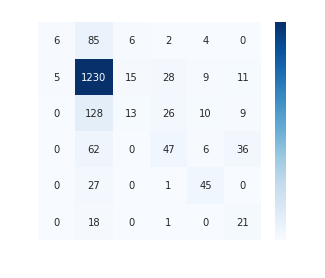

In [716]:
cm = confusion_matrix(y_oCBD, y_pred_oCBD)
cm_df = pd.DataFrame(cm, index=output_categories, columns=output_categories)

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [724]:
f2_oCBD = fbeta_score(y_oCBD, y_pred_oCBD, beta=2, average='weighted')
print(classification_report(y_oCBD, y_pred_oCBD, target_names=output_categories, zero_division=0))
print("F2 Measure is {0:.2f}".format(f2_oCBD))

              precision    recall  f1-score   support

         bus       0.55      0.06      0.11       103
         car       0.79      0.95      0.86      1298
       train       0.38      0.07      0.12       186
        walk       0.45      0.31      0.37       151
        bike       0.61      0.62      0.61        73
       motor       0.27      0.53      0.36        40

    accuracy                           0.74      1851
   macro avg       0.51      0.42      0.40      1851
weighted avg       0.69      0.74      0.69      1851

F2 Measure is 0.71


### Testing data results

In [721]:
avail_vals_iCBD = generate_avail_data(X_iCBD.values)
y_pred_iCBD = predict(X_iCBD.columns, X_iCBD.values, results.position, 
                 avail_vals_iCBD, ind_spec_vars_list=ind_spec_vars)[1].numpy() + 1

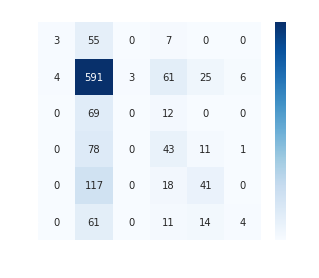

In [722]:
cm = confusion_matrix(y_iCBD, y_pred_iCBD)
cm_df = pd.DataFrame(cm, index=output_categories, columns=output_categories)

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [723]:
print(classification_report(y_iCBD, y_pred_iCBD, target_names=output_categories, zero_division=0))
f2_iCBD = fbeta_score(y_iCBD, y_pred_iCBD, beta=2, average='weighted')
print("F2 measure for iCBD data is {0:.2f}".format(f2_iCBD))

              precision    recall  f1-score   support

         bus       0.43      0.05      0.08        65
         car       0.61      0.86      0.71       690
       train       0.00      0.00      0.00        81
        walk       0.28      0.32      0.30       133
        bike       0.45      0.23      0.31       176
       motor       0.36      0.04      0.08        90

    accuracy                           0.55      1235
   macro avg       0.36      0.25      0.25      1235
weighted avg       0.48      0.55      0.48      1235

F2 measure for iCBD data is 0.52


## Negative log likelihood and other metrics

In [116]:
ohe_true_y = tf.one_hot(y_train-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_train)
x_names = X_train.columns
x_vals = X_train.values

initial_mean_negLL_train = loss_val_nd_loss_grad(X_train.columns, X_train.values, params, 
                      lambda1, lambda2, ind_spec_vars=ind_spec_vars)
final_mean_negLL_train = loss_val_nd_loss_grad(X_train.columns, X_train.values, results.position, 
                      lambda1, lambda2, ind_spec_vars=ind_spec_vars)
AIC_train = 2*(len(result_df)+final_mean_negLL_train*len(df2))
print(f"Initial Training log loss: {-initial_mean_negLL_train*len(df2):.2f}")
print(f'Final Training log loss: {-final_mean_negLL_train*len(df2):.2f}')
print(f"Training AIC value: {AIC_train:.2f}")

print("**************************************************************")

ohe_true_y = tf.one_hot(y_test-1, 6, on_value=1, off_value=0, axis=-1, dtype='float32')
avail_vals = generate_avail_data(X_test)
x_names = X_test.columns
x_vals = X_test.values

initial_mean_negLL_test = loss_val_nd_loss_grad(X_test.columns, X_test.values, params, 
                      lambda1, lambda2, ind_spec_vars=ind_spec_vars)
final_mean_negLL_test = loss_val_nd_loss_grad(X_test.columns, X_test.values, results.position, 
                      lambda1, lambda2, ind_spec_vars=ind_spec_vars)
AIC_test = 2*(len(result_df)+final_mean_negLL_test*len(df2))
print(f"Initial Testing log loss: {-initial_mean_negLL_test*len(df2):.2f}")
print(f'Final Testing log loss: {-final_mean_negLL_test*len(df2):.2f}')
print(f"Testing AIC value: {AIC_test:.2f}")

Initial Training log loss: -3261.21
Final Training log loss: -2236.43
Training AIC value: 4488.86
**************************************************************
Initial Testing log loss: -3988.77
Final Testing log loss: -3074.73
Testing AIC value: 6165.46


In [117]:
classical_res = pd.read_csv('classical_model/MNL_2762023_estimates.csv')
classical_res.rename(columns={'Unnamed: 0':'variable'}, inplace=True)
classical_res['variable'] = ['asc_bike', 'asc_bus', 'asc_motor', 'asc_train', 'asc_walk', 'gen_tc', 'gen_tt', 'gen_ti']
classical_res

,variable,Estimate,Std.err.,t-ratio(0),Rob.std.err.,Rob.t-ratio(0)
0,asc_bike,-1.73e-01,8.56e-02,-2.02,2.45e-01,-0.71
1,asc_bus,-4.91e-01,1.58e-01,-3.11,4.07e-01,-1.21
2,asc_motor,-1.91e-01,1.15e-01,-1.66,4.19e-01,-0.45
3,asc_train,-7.26e-01,1.14e-01,-6.38,3.78e-01,-1.92
4,asc_walk,3.65e-02,1.12e-01,0.33,3.15e-01,0.12
5,gen_tc,-1.92e-03,3.28e-04,-5.87,7.71e-04,-2.50
6,gen_tt,-5.94e-02,3.64e-03,-16.31,1.44e-02,-4.12
7,gen_ti,1.95e-03,2.58e-04,7.57,5.79e-04,3.38


## <ins><b>Comparing Test and Train Fit</b></ins>

In [119]:
train_report = classification_report(y_train, y_pred_train, target_names=output_categories, zero_division=0, output_dict=True)
train_report['final_neg_log_loss'] = final_mean_negLL_train
train_report['f2-score']=f2_train

train_report.update(train_report['macro avg'])
to_rem = ['bus', 'car', 'train', 'walk', 'bike', 'motor', 'macro avg', 'weighted avg']
for val in to_rem:
    del train_report[val]
train_test_report = {'train': train_report}

In [120]:
test_report = classification_report(y_test, y_pred_test, target_names=output_categories, zero_division=0, output_dict=True)
test_report['final_neg_log_loss'] = final_mean_negLL_test
test_report['f2-score'] = f2_test

test_report.update(test_report['macro avg'])
for val in to_rem:
    del test_report[val]
train_test_report['test'] = test_report

In [121]:
final_report = pd.DataFrame.from_dict(train_test_report).drop(['f1-score', 'accuracy', 'precision', 'recall'], axis=0).rename(index={'support':'total_trips'})
final_report

,train,test
final_neg_log_loss,0.72,1.00
f2-score,0.41,0.25
total_trips,1851.00,864.00


## <b><ins>Model Logging</ins></b>

In [123]:
l2_lambda=lambda2; l1_lambda=lambda1

models = os.listdir('model_reports')
nmod = len(models)
dir_path = f'model_reports//model_{nmod+1}'
os.mkdir(dir_path)

result_df.to_csv(f'{dir_path}//params.csv')
final_report.to_csv(f"{dir_path}//report.csv")

preprocess_info = f"Trained on trips originating outside CBD.\nNo outlier removal.\nNo Standardization.\nNo smote.\nNo Tomek links.\n"
regularization_info = f'Parameters of Alternative specific variables under l2 penalty with lambda {l2_lambda}.\nParams of individual specific variables under l1 penalty with lambda {l1_lambda}.\n'
final_info = preprocess_info + regularization_info

with open(f'{dir_path}//info.txt', 'w') as f:
    f.write(final_info)
    f.close()

In [ ]:
# Best params for travel variables only: l2 = 1
# Best params for travel, age, female, high_income, and dist variables, l1 = 100, l2 = 100